## Borrar para iniciar desde 0

In [ ]:
# Fase 1: Descartar todos los cambios locales y volver a la rama de trabajo
!git reset --hard HEAD  # Deshace cualquier cambio no confirmado
!git checkout main # Vuelve a la rama de trabajo

# Fase 2: Eliminar la estructura del proyecto y archivos clave
!rm -rf src             # Borra el código fuente (prepare.py, train.py)
!rm -rf data/processed  # Borra los datos procesados
!rm -rf models          # Borra los modelos entrenados
!rm dvc.yaml            # Borra el archivo de pipeline de DVC
!rm metrics.json        # Borra el archivo de métricas (si existe)

# Fase 3: Eliminar archivos internos de DVC
!rm -rf .dvc/cache      # Borra el caché de DVC (donde están los datos grandes)
!rm -rf .dvc/tmp        # Borra los archivos temporales de DVC

# Fase 4: Limpiar archivos no rastreados
!git clean -fd          # Elimina archivos y directorios no rastreados por Git (la limpieza más agresiva)

# Fase 5: Descartar todos los cambios locales y limpiar el área de trabajo
!git reset --hard HEAD
!git checkout main # Vuelve a la rama de trabajo
!git clean -fd

# Fase 6: Eliminar la estructura de archivos generados por el pipeline
!rm -rf .dvc
!rm -rf data
!rm -rf mlruns
!rm -rf notebooks
!rm -rf .dvcignore
!rm -rf .gitignore
!rm -rf README.md
!rm -rf src             # Borra el código fuente
!rm -rf data/processed  # Borra los datos procesados
!rm -rf models          # Borra los modelos entrenados
!rm dvc.yaml            # Borra el archivo de pipeline
!rm metrics.json        # Borra el archivo de métricas

# Fase 7: Eliminar archivos internos temporales de DVC
!rm -rf .dvc/tmp


print("✅ Limpieza completada. El repositorio está en el último commit de la rama 'feature/eda' sin archivos temporales ni generados.")

# O. Estructura Inicial del proyecto

In [1]:
from pathlib import Path

for p in ['data/raw', 'data/processed', 'models', 'notebooks', 'src', 'tests', 'scripts']:
    Path(p).mkdir(parents=True, exist_ok=True)

Path('README.md').write_text('# Proyecto MLOps - Taller de Control de Cambios\n')
gitignore = (
    '# Python\n'
    '__pycache__/\n'
    '*.pyc\n'
    '.venv/\n'
    'venv/\n'
    '.env\n'
    '# Jupyter\n'
    '.ipynb_checkpoints/\n'
    "# DVC (¡no ignores .dvc ni *.dvc!)\n"
    "!.dvc\n"
    "!.dvc/**\n"
    "!.dvcignore\n"
    "# Artefactos locales (no versionar)\n"
    "mlruns/\n"
    "models/*.pkl\n"
    "metrics.json\n"
    '# OS\n'
    '.DS_Store\n'
)
Path('.gitignore').write_text(gitignore)
print('Estructura creada.')



Estructura creada.


# 0.1 Inicializa Git y primer commit

In [2]:
!git init
!git add .
!git commit -m "chore: inicializa estructura base del proyecto"
!git branch -M main
!git log --oneline -n 1

Reinitialized existing Git repository in /Users/santiagoaristizabalnorena/Library/CloudStorage/GoogleDrive-santiago.aristizabaln@uqvirtual.edu.co/Mi unidad/1. Maestria en Ingenieria (Analitica de Datos)/2. Segundo semestre/1. Materias/3. Gerencia de Proyectos de Analitica de Datos/Proyecto/.git/
[feature/eda a59cba4] chore: inicializa estructura base del proyecto
 7 files changed, 23 deletions(-)
 delete mode 100644 .dvc/.gitignore
 delete mode 100644 .dvc/config
 delete mode 100644 .dvcignore
 delete mode 100644 data/raw/.gitignore
 delete mode 100644 data/raw/UCI_Credit_Card.csv.dvc
 delete mode 100644 notebooks/eda_placeholder.ipynb
 delete mode 100644 src/train.py
a59cba4 (HEAD -> main) chore: inicializa estructura base del proyecto


In [3]:
import shutil
import os

# --- Rutas de Archivos ---

# 1. Ruta del archivo original (donde está actualmente tu dataset)
# Usaremos la ruta completa que has estado utilizando:
RUTA_ORIGINAL_ARCHIVO = '/Users/santiagoaristizabalnorena/Library/CloudStorage/GoogleDrive-santiago.aristizabaln@uqvirtual.edu.co/Mi unidad/1. Maestria en Ingenieria (Analitica de Datos)/2. Segundo semestre/1. Materias/3. Gerencia de Proyectos de Analitica de Datos/Proyecto/UCI_Credit_Card.csv'

# 2. Carpeta de destino (donde queremos que esté el dataset)
# Asumimos que estás ejecutando esto desde la raíz del proyecto donde creaste la carpeta 'data/raw'
CARPETA_DESTINO = 'data/raw'

# 3. Ruta final del archivo
RUTA_FINAL_ARCHIVO = os.path.join(CARPETA_DESTINO, 'UCI_Credit_Card.csv')

# --- Operación de Movimiento ---

try:
    # shutil.move mueve el archivo de la RUTA_ORIGINAL_ARCHIVO a la RUTA_FINAL_ARCHIVO
    shutil.move(RUTA_ORIGINAL_ARCHIVO, RUTA_FINAL_ARCHIVO)
    
    print("✅ ¡Dataset movido exitosamente!")
    print(f"El archivo ahora se encuentra en: {RUTA_FINAL_ARCHIVO}")

except FileNotFoundError:
    print("❌ ERROR: No se encontró el archivo original.")
    print(f"Verifica que esta ruta sea correcta: {RUTA_ORIGINAL_ARCHIVO}")

except shutil.Error as e:
    # Esto puede ocurrir si el archivo ya existe en el destino, o si hay un problema de permisos
    if "already exists" in str(e):
         print(f"⚠️ Aviso: El archivo ya existe en {RUTA_FINAL_ARCHIVO}. Asumiendo que ya fue movido.")
    else:
        print(f"❌ Ocurrió un error al mover el archivo: {e}")

except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

✅ ¡Dataset movido exitosamente!
El archivo ahora se encuentra en: data/raw/UCI_Credit_Card.csv


# 1 Cargar de datos

In [4]:
import pandas as pd
import os

# --- ADJUSTED PATH ---
# The file is now located inside the project structure, 
# relative to where you run this script.
ruta_local = 'data/raw/UCI_Credit_Card.csv'

# Carga el archivo en un DataFrame de pandas
try:
    df = pd.read_csv(ruta_local)
    print("✅ Archivo CSV cargado exitosamente en pandas (DataFrame 'df') desde la carpeta data/raw.")
    print("\nPrimeras 5 filas del archivo:")
    print(df.head())
    print("\nInformación del DataFrame:")
    print(df.info())

except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo en la ruta: {ruta_local}")
    print("Asegúrate de que el archivo 'UCI_Credit_Card.csv' esté en la carpeta 'data/raw' y que estás ejecutando el script desde la raíz del proyecto.")
except Exception as e:
    print(f"❌ Ocurrió un error al cargar el archivo: {e}")

✅ Archivo CSV cargado exitosamente en pandas (DataFrame 'df') desde la carpeta data/raw.

Primeras 5 filas del archivo:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0 

# 2. Limpieza de datos

In [5]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# --- RUTAS DE ARCHIVOS ---
RUTA_DATASET_RAW = 'data/raw/UCI_Credit_Card.csv'
CARPETA_PROCESSED = 'data/processed'
RUTA_GUARDADO = os.path.join(CARPETA_PROCESSED, 'UCI_Credit_Card_Limpio.csv')

# --- CARGA DEL DATASET ---
try:
    df = pd.read_csv(RUTA_DATASET_RAW)
    print(f"✅ Archivo cargado exitosamente desde: {RUTA_DATASET_RAW}")
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado en la ruta {RUTA_DATASET_RAW}.")
    exit()

# --- 1. NORMALIZACIÓN INICIAL Y EXPLORACIÓN ---
# 1.1 Normalización de nombres de columnas (minúsculas y guiones bajos)
df.columns = df.columns.str.lower().str.replace('[^a-z0-9_]+', '_', regex=True)
print("\nNombres de columnas normalizados.")

# 1.2 Información General
print("\n--- 1. Información General ---")
print(f"Dimensiones iniciales del DataFrame: {df.shape}")
df.info()
print("-" * 50)


# --- 2. MANEJO DE DUPLICADOS ---
print("--- 2. Datos Duplicados ---")
# Contamos y eliminamos duplicados (excluyendo la columna 'id')
filas_duplicadas = df.drop(columns=['id'], errors='ignore').duplicated().sum() 
print(f"Número de filas duplicadas encontradas (excluyendo ID): {filas_duplicadas}")

if filas_duplicadas > 0:
    df.drop_duplicates(subset=df.columns.drop('id', errors='ignore'), inplace=True)
    print(f"Se eliminaron {filas_duplicadas} filas duplicadas.")
print(f"Dimensiones después de eliminar duplicados: {df.shape}")
print("-" * 50)


# --- 3. CORRECCIÓN DE VALORES ANÓMALOS CATEÓRICOS (ESPECÍFICO DE UCI DATASET) ---
print("--- 3. Corrección de Valores Anómalos Categóricos ---")

# 3.1 Normalización de 'education' (0, 5, 6 -> 4 [Otros/Desconocido])
df['education'].replace({0: 4, 5: 4, 6: 4}, inplace=True)
print("Normalizado: 'education'.")

# 3.2 Normalización de 'marriage' (0 -> 3 [Otros/Desconocido])
df['marriage'].replace({0: 3}, inplace=True)
print("Normalizado: 'marriage'.")

print("-" * 50)


# --- 4. MANEJO DE VALORES FALTANTES (NaN / Null) ---
print("--- 4. Valores Faltantes ---")
valores_faltantes = df.isnull().sum()
print("Cantidad de NaN por columna:\n", valores_faltantes[valores_faltantes > 0])
print("-" * 50)


# --- 5. GUARDA DEL DATASET LIMPIO EN data/processed ---
# Aseguramos que la carpeta exista
Path(CARPETA_PROCESSED).mkdir(parents=True, exist_ok=True)

try:
    df.to_csv(RUTA_GUARDADO, index=False)
    print("\n--- ¡LIMPIEZA AVANZADA COMPLETADA Y GUARDADA! ---")
    print(f"✅ Archivo limpio guardado en: {RUTA_GUARDADO}")
    print(f"DataFrame final con {df.shape[0]} filas y {df.shape[1]} columnas.")
except Exception as e:
    print(f"❌ ERROR al intentar guardar el archivo: {e}")

✅ Archivo cargado exitosamente desde: data/raw/UCI_Credit_Card.csv

Nombres de columnas normalizados.

--- 1. Información General ---
Dimensiones iniciales del DataFrame: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          30000 non-null  int64  
 1   limit_bal                   30000 non-null  float64
 2   sex                         30000 non-null  int64  
 3   education                   30000 non-null  int64  
 4   marriage                    30000 non-null  int64  
 5   age                         30000 non-null  int64  
 6   pay_0                       30000 non-null  int64  
 7   pay_2                       30000 non-null  int64  
 8   pay_3                       30000 non-null  int64  
 9   pay_4                       30000 non-null  int64  
 10  pay_5              

/var/folders/1g/nr3xwgyx10zbg7z077n6whzh0000gn/T/ipykernel_50510/485514749.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].replace({0: 4, 5: 4, 6: 4}, inplace=True)
/var/folders/1g/nr3xwgyx10zbg7z077n6whzh0000gn/T/ipykernel_50510/485514749.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

# 3. Processed

In [6]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# --- RUTAS DE ARCHIVOS ---
RUTA_DATASET_LIMPIO = 'data/processed/UCI_Credit_Card_Limpio.csv'
CARPETA_GUARDADO = 'data/processed'

# --- CARGA DE DATOS ---
try:
    df = pd.read_csv(RUTA_DATASET_LIMPIO)
    print(f"✅ DataFrame limpio cargado desde: {RUTA_DATASET_LIMPIO}")
except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo limpio en {RUTA_DATASET_LIMPIO}.")
    exit()

print("\n--- Inicio del Procesamiento de Datos ---")
# -------------------------------------------------------------------------


# --- 1. DEFINICIÓN DE VARIABLES ---
TARGET_COLUMN = 'default_payment_next_month'

# Excluimos 'id'
df.drop('id', axis=1, inplace=True, errors='ignore')

# Separación de X (características) e y (objetivo)
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print(f"Variable Objetivo (y): {TARGET_COLUMN}")
print("-" * 30)


# --- 2. IDENTIFICACIÓN DE COLUMNAS (Nombres Normalizados) ---
numerical_features = [
    'limit_bal', 'age', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4',
    'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4',
    'pay_amt5', 'pay_amt6'
]
categorical_features = [
    'sex', 'education', 'marriage', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6'
]

print(f"Columnas Numéricas a Escalar: {len(numerical_features)}")
print(f"Columnas Categóricas a Codificar: {len(categorical_features)}")
print("-" * 30)


# --- 3. CREACIÓN DE PIPELINE DE TRANSFORMACIÓN ---
numerical_transformer = StandardScaler()
# El ColumnTransformer producirá una matriz dispersa (csr_matrix)
categorical_transformer = OneHotEncoder(handle_unknown='ignore') 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("Pipeline de preprocesamiento creado.")
print("-" * 30)


# --- 4. DIVISIÓN DEL DATASET ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 5. APLICACIÓN DEL PIPELINE Y GUARDADO ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Guardar el objeto 'preprocessor' para usarlo en producción
joblib.dump(preprocessor, os.path.join(CARPETA_GUARDADO, 'preprocessor.pkl'))
print(f"✅ Objeto 'preprocessor' guardado.")

# Guardar los arreglos de NumPy
np.save(os.path.join(CARPETA_GUARDADO, 'X_train_processed.npy'), X_train_processed)
np.save(os.path.join(CARPETA_GUARDADO, 'X_test_processed.npy'), X_test_processed)
np.save(os.path.join(CARPETA_GUARDADO, 'y_train.npy'), y_train)
np.save(os.path.join(CARPETA_GUARDADO, 'y_test.npy'), y_test)

print("\n--- Guardado de Datos Procesados ---")
print(f"Archivos .npy guardados exitosamente en: {CARPETA_GUARDADO}")
print(f"X_train_processed shape final: {X_train_processed.shape}")

✅ DataFrame limpio cargado desde: data/processed/UCI_Credit_Card_Limpio.csv

--- Inicio del Procesamiento de Datos ---
Variable Objetivo (y): default_payment_next_month
------------------------------
Columnas Numéricas a Escalar: 14
Columnas Categóricas a Codificar: 9
------------------------------
Pipeline de preprocesamiento creado.
------------------------------
✅ Objeto 'preprocessor' guardado.

--- Guardado de Datos Procesados ---
Archivos .npy guardados exitosamente en: data/processed
X_train_processed shape final: (23972, 86)


# 4. Testeo

In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


--- Carga de Datos Procesados y Conversión a Arreglo Denso ---
Convertido X_train y X_test de matriz dispersa a arreglo denso.
✅ Datos cargados y preparados exitosamente.
--------------------------------------------------
--- 1. Entrenamiento del Modelo ---
Modelo de Regresión Logística entrenado exitosamente.
✅ Modelo guardado en: models/modelo_regresion_logistica.pkl
--------------------------------------------------
--- 2. Generación de Predicciones y Evaluación ---
Precisión (Accuracy): 0.8205
AUC-ROC Score: 0.7613
F1-Score: 0.4652
--------------------------------------------------

Reporte de Clasificación:
                precision    recall  f1-score   support

No Default (0)       0.84      0.95      0.89      4667
   Default (1)       0.68      0.35      0.47      1326

      accuracy                           0.82      5993
     macro avg       0.76      0.65      0.68      5993
  weighted avg       0.80      0.82      0.80      5993


Matriz de Confusión (Array de NumPy):
[[

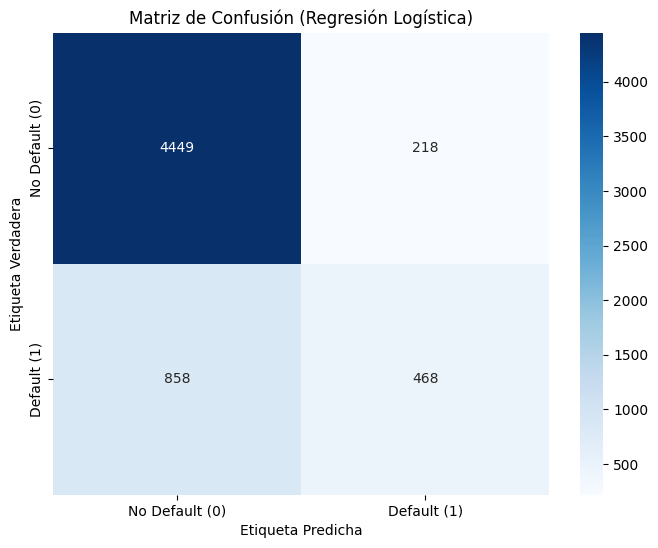

--------------------------------------------------
✅ Testeo del modelo completado y evaluado.


In [ ]:
import numpy as np
import os
import joblib
import json
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# --- RUTAS Y CARGA DE DATOS ---
CARPETA_PROCESSED = 'data/processed'
CARPETA_MODELOS = 'models'

print("--- Carga de Datos Procesados y Conversión a Arreglo Denso ---")
try:
    # 1. Cargar los datos procesados desde archivos .npy
    # Usamos allow_pickle=True para que NumPy pueda manejar objetos CSR Matrix
    X_train_processed = np.load(os.path.join(CARPETA_PROCESSED, 'X_train_processed.npy'), allow_pickle=True).item()
    X_test_processed = np.load(os.path.join(CARPETA_PROCESSED, 'X_test_processed.npy'), allow_pickle=True).item()
    y_train = np.load(os.path.join(CARPETA_PROCESSED, 'y_train.npy'), allow_pickle=True)
    y_test = np.load(os.path.join(CARPETA_PROCESSED, 'y_test.npy'), allow_pickle=True)
    
    # 2. CORRECCIÓN CLAVE: Convertir explícitamente a formato denso (.toarray())
    # NOTA: Usamos .item() en la carga porque a veces np.save guarda la matriz dispersa 
    # dentro de un array de NumPy de un solo elemento (lo cual requiere .item() para acceder al CSR Matrix).
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()
    
    print("Convertido X_train y X_test de matriz dispersa a arreglo denso.")
    print("✅ Datos cargados y preparados exitosamente.")
except FileNotFoundError:
    print(f"❌ ERROR: Archivos .npy no encontrados en {CARPETA_PROCESSED}.")
    exit()
except AttributeError:
     # Captura si el .toarray() falla, indicando que el objeto no es una matriz dispersa válida.
     print("⚠️ Aviso: El objeto cargado no es una matriz dispersa. Intentando usarlo directamente...")
except Exception as e:
    print(f"❌ Ocurrió un error inesperado durante la carga/conversión: {e}")
    exit()

print("-" * 50)

## 📈 Entrenamiento y Testeo del Modelo

# --- 1. ENTRENAMIENTO DEL MODELO ---
print("--- 1. Entrenamiento del Modelo ---")
modelo = LogisticRegression(solver='liblinear', random_state=42)
modelo.fit(X_train_processed, y_train) 
print("Modelo de Regresión Logística entrenado exitosamente.")

# Guardar el modelo entrenado
RUTA_MODELO_GUARDADO = os.path.join(CARPETA_MODELOS, 'modelo_regresion_logistica.pkl')
joblib.dump(modelo, RUTA_MODELO_GUARDADO)
print(f"✅ Modelo guardado en: {RUTA_MODELO_GUARDADO}")
print("-" * 50)


# --- 2. GENERACIÓN DE PREDICCIONES Y EVALUACIÓN ---
print("--- 2. Generación de Predicciones y Evaluación ---")

y_pred = modelo.predict(X_test_processed)
y_prob = modelo.predict_proba(X_test_processed)[:, 1]

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

with open('metrics.json', 'w') as f:
    json.dump({'accuracy': accuracy}, f)
    json.dump({'roc_auc': roc_auc}, f)
    json.dump({'f1': f1}, f)

print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"AUC-ROC Score: {roc_auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

# Reporte de Clasificación Detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Default (0)', 'Default (1)']))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión (Array de NumPy):")
print(conf_matrix)

# Visualización (requiere Matplotlib/Seaborn instalados)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Matriz de Confusión (Regresión Logística)')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("-" * 50)
print("✅ Testeo del modelo completado y evaluado.")

# 5. Versionamiento de datos con DVC

In [4]:
%pip -q install "dvc[gs,s3]==3.*" "pandas==2.*"

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!dvc init -q
!dvc add data/raw/UCI_Credit_Card.csv
!dvc add data/processed/UCI_Credit_Card_Limpio.csv
!git add data/raw/.gitignore data/raw/UCI_Credit_Card.csv.dvc .dvc .dvcignore
!git add data/processed/.gitignore data/processed/UCI_Credit_Card_Limpio.csv.dvc .dvc .dvcignore
!git commit -m "data: versiona dataset UCI_Credit_Default con DVC"
!dvc status

 ⠋ Checking graph
Adding...                                                                       
!
                                                                                
!
  0% Checking cache in '/Users/santiagoaristizabalnorena/Library/CloudStorage/Go
                                                                                
!
  0%|          |Adding data/raw/UCI_Credit_Card.csv to0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /Users/santiagoaristizaba0/1 [00:00<?,    ?files/s]
100% Adding...|████████████████████████████████████████|1/1 [00:00, 30.17file/s]

To track the changes with git, run:

	git add .dvc/.gitignore data/raw/UCI_Credit_Card.csv.dvc data/raw/.gitignore

To enable auto staging, run:

	dvc config core.autostage true
[feature/eda fe7074b] data: versiona dataset UCI_Credit_Default con DVC
 5 files changed, 18 insertions(+)
 create mode 100644 .dvc/.gitignore
 cre

# 6. Registro de experimentos y modelos con MLflow

In [2]:
%pip -q install "mlflow==2.*" "scikit-learn==1.*" "joblib==1.*"

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import os
import joblib
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# --- RUTAS DE ARCHIVOS Y CARGA DE DATOS ---
CARPETA_PROCESSED = 'data/processed'
RUTA_PREPROCESSOR = os.path.join(CARPETA_PROCESSED, 'preprocessor.pkl')

print("--- 1. Carga de Datos Procesados ---")
try:
    # Cargar los datos procesados con la corrección de la matriz dispersa
    X_train_processed = np.load(os.path.join(CARPETA_PROCESSED, 'X_train_processed.npy'), allow_pickle=True).item().toarray()
    X_test_processed = np.load(os.path.join(CARPETA_PROCESSED, 'X_test_processed.npy'), allow_pickle=True).item().toarray()
    y_train = np.load(os.path.join(CARPETA_PROCESSED, 'y_train.npy'), allow_pickle=True)
    y_test = np.load(os.path.join(CARPETA_PROCESSED, 'y_test.npy'), allow_pickle=True)
    
    # Cargar el preprocesador
    preprocessor = joblib.load(RUTA_PREPROCESSOR)

    print("✅ Datos cargados y preparados exitosamente.")
except Exception as e:
    print(f"❌ ERROR al cargar datos o preprocesador: {e}")
    exit()

print("-" * 50)

# --- 2. ENTRENAMIENTO Y REGISTRO CON MLFLOW ---

# 🚨 CORRECCIÓN AQUÍ: Usamos una ruta relativa para evitar el error de "Read-only file system"
mlflow.set_tracking_uri("file:./mlruns") 
mlflow.set_experiment("Credit_Default_Prediction")

# El modelo ya está preprocesado, solo entrenamos el clasificador directamente
MODEL_NAME = 'RandomForestClassifier'

with mlflow.start_run(run_name=f'{MODEL_NAME}_baseline') as run:
    print(f"--- 2. Entrenando Modelo: {MODEL_NAME} ---")

    # 1. Instanciar el modelo (RandomForest)
    # Se incluye class_weight='balanced' para mejorar el manejo del desbalance de clases
    modelo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    
    # 2. Entrenar
    modelo.fit(X_train_processed, y_train)
    
    # 3. Generar predicciones
    y_pred = modelo.predict(X_test_processed)
    y_prob = modelo.predict_proba(X_test_processed)[:, 1]

    # 4. Calcular métricas clave
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)

    # 5. Registrar parámetros y métricas en MLflow
    mlflow.log_param('model_type', MODEL_NAME)
    mlflow.log_param('n_estimators', modelo.get_params()['n_estimators'])
    mlflow.log_param('class_weight', 'balanced')
    
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('roc_auc', roc_auc)
    mlflow.log_metric('f1_score', f1)
    
    # 6. Guardar el modelo como artefacto de MLflow
    mlflow.sklearn.log_model(modelo, 'random_forest_model')

    print("\n--- ✅ REGISTRO Y EVALUACIÓN COMPLETADA ---")
    print(f"Run ID: {run.info.run_id}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC-ROC Score: {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Mostrar el reporte detallado
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

print("-" * 50)
print("El modelo y sus métricas han sido registrados en MLflow.")



2025/11/08 22:10:12 INFO mlflow.tracking.fluent: Experiment with name 'Credit_Default_Prediction' does not exist. Creating a new experiment.


--- 1. Carga de Datos Procesados ---
✅ Datos cargados y preparados exitosamente.
--------------------------------------------------
--- 2. Entrenando Modelo: RandomForestClassifier ---


2025/11/08 22:10:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



--- ✅ REGISTRO Y EVALUACIÓN COMPLETADA ---
Run ID: afd37c13f9bc4aad8f42d4f887f5b93e
Accuracy: 0.8141
AUC-ROC Score: 0.7637
F1-Score: 0.4507

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4667
           1       0.65      0.34      0.45      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993

--------------------------------------------------
El modelo y sus métricas han sido registrados en MLflow.


# 12. Creación de archivos (`limpieza.py, processed.py, testeo.py, dvc.yaml`)

In [10]:
from pathlib import Path
import os
import joblib

# 1. Asegura que las carpetas existan
Path('src').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# 2. CONTENIDO AJUSTADO DE src/limpieza.py (Limpieza y Preprocesamiento Avanzado)
# ----------------------------------------------------------------------
limpieza_py = """import pandas as pd
import numpy as np
import os
from pathlib import Path

# --- RUTAS DE ARCHIVOS ---
RUTA_DATASET_RAW = 'data/raw/UCI_Credit_Card.csv'
CARPETA_PROCESSED = 'data/processed'
RUTA_GUARDADO = os.path.join(CARPETA_PROCESSED, 'UCI_Credit_Card_Limpio.csv')

# --- CARGA DEL DATASET ---
try:
    df = pd.read_csv(RUTA_DATASET_RAW)
    print(f"✅ Archivo cargado exitosamente desde: {RUTA_DATASET_RAW}")
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado en la ruta {RUTA_DATASET_RAW}.")
    exit()

# --- 1. NORMALIZACIÓN INICIAL Y EXPLORACIÓN ---
# 1.1 Normalización de nombres de columnas (minúsculas y guiones bajos)
df.columns = df.columns.str.lower().str.replace('[^a-z0-9_]+', '_', regex=True)
print("Nombres de columnas normalizados.")

# 1.2 Información General
print("--- 1. Información General ---")
print(f"Dimensiones iniciales del DataFrame: {df.shape}")
df.info()
print("-" * 50)


# --- 2. MANEJO DE DUPLICADOS ---
print("--- 2. Datos Duplicados ---")
# Contamos y eliminamos duplicados (excluyendo la columna 'id')
filas_duplicadas = df.drop(columns=['id'], errors='ignore').duplicated().sum() 
print(f"Número de filas duplicadas encontradas (excluyendo ID): {filas_duplicadas}")

if filas_duplicadas > 0:
    df.drop_duplicates(subset=df.columns.drop('id', errors='ignore'), inplace=True)
    print(f"Se eliminaron {filas_duplicadas} filas duplicadas.")
print(f"Dimensiones después de eliminar duplicados: {df.shape}")
print("-" * 50)


# --- 3. CORRECCIÓN DE VALORES ANÓMALOS CATEÓRICOS (ESPECÍFICO DE UCI DATASET) ---
print("--- 3. Corrección de Valores Anómalos Categóricos ---")

# 3.1 Normalización de 'education' (0, 5, 6 -> 4 [Otros/Desconocido])
df['education'].replace({0: 4, 5: 4, 6: 4}, inplace=True)
print("Normalizado: 'education'.")

# 3.2 Normalización de 'marriage' (0 -> 3 [Otros/Desconocido])
df['marriage'].replace({0: 3}, inplace=True)
print("Normalizado: 'marriage'.")

print("-" * 50)


# --- 4. MANEJO DE VALORES FALTANTES (NaN / Null) ---
print("--- 4. Valores Faltantes ---")
valores_faltantes = df.isnull().sum()
print("Cantidad de NaN por columna:", valores_faltantes[valores_faltantes > 0])
print("-" * 50)


# --- 5. GUARDA DEL DATASET LIMPIO EN data/processed ---
# Aseguramos que la carpeta exista
Path(CARPETA_PROCESSED).mkdir(parents=True, exist_ok=True)

try:
    df.to_csv(RUTA_GUARDADO, index=False)
    print("--- ¡LIMPIEZA AVANZADA COMPLETADA Y GUARDADA! ---")
    print(f"✅ Archivo limpio guardado en: {RUTA_GUARDADO}")
    print(f"DataFrame final con {df.shape[0]} filas y {df.shape[1]} columnas.")
except Exception as e:
    print(f"❌ ERROR al intentar guardar el archivo: {e}")
"""
Path('src/limpieza.py').write_text(limpieza_py)

# ----------------------------------------------------------------------
# 3. CONTENIDO AJUSTADO DE src/processed.py (Carga .npy, Manejo de Sparse Matrix y Entrenamiento)
# ----------------------------------------------------------------------
processed_py = """import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# --- RUTAS DE ARCHIVOS ---
RUTA_DATASET_LIMPIO = 'data/processed/UCI_Credit_Card_Limpio.csv'
CARPETA_GUARDADO = 'data/processed'

# --- CARGA DE DATOS ---
try:
    df = pd.read_csv(RUTA_DATASET_LIMPIO)
    print(f"✅ DataFrame limpio cargado desde: {RUTA_DATASET_LIMPIO}")
except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo limpio en {RUTA_DATASET_LIMPIO}.")
    exit()

print("\n--- Inicio del Procesamiento de Datos ---")
# -------------------------------------------------------------------------


# --- 1. DEFINICIÓN DE VARIABLES ---
TARGET_COLUMN = 'default_payment_next_month'

# Excluimos 'id'
df.drop('id', axis=1, inplace=True, errors='ignore')

# Separación de X (características) e y (objetivo)
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print(f"Variable Objetivo (y): {TARGET_COLUMN}")
print("-" * 30)


# --- 2. IDENTIFICACIÓN DE COLUMNAS (Nombres Normalizados) ---
numerical_features = [
    'limit_bal', 'age', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4',
    'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4',
    'pay_amt5', 'pay_amt6'
]
categorical_features = [
    'sex', 'education', 'marriage', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6'
]

print(f"Columnas Numéricas a Escalar: {len(numerical_features)}")
print(f"Columnas Categóricas a Codificar: {len(categorical_features)}")
print("-" * 30)


# --- 3. CREACIÓN DE PIPELINE DE TRANSFORMACIÓN ---
numerical_transformer = StandardScaler()
# El ColumnTransformer producirá una matriz dispersa (csr_matrix)
categorical_transformer = OneHotEncoder(handle_unknown='ignore') 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("Pipeline de preprocesamiento creado.")
print("-" * 30)


# --- 4. DIVISIÓN DEL DATASET ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 5. APLICACIÓN DEL PIPELINE Y GUARDADO ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Guardar el objeto 'preprocessor' para usarlo en producción
joblib.dump(preprocessor, os.path.join(CARPETA_GUARDADO, 'preprocessor.pkl'))
print(f"✅ Objeto 'preprocessor' guardado.")

# Guardar los arreglos de NumPy
np.save(os.path.join(CARPETA_GUARDADO, 'X_train_processed.npy'), X_train_processed)
np.save(os.path.join(CARPETA_GUARDADO, 'X_test_processed.npy'), X_test_processed)
np.save(os.path.join(CARPETA_GUARDADO, 'y_train.npy'), y_train)
np.save(os.path.join(CARPETA_GUARDADO, 'y_test.npy'), y_test)

print("\n--- Guardado de Datos Procesados ---")
print(f"Archivos .npy guardados exitosamente en: {CARPETA_GUARDADO}")
print(f"X_train_processed shape final: {X_train_processed.shape}")
"""
Path('src/processed.py').write_text(processed_py)

# ----------------------------------------------------------------------
# 4. CONTENIDO AJUSTADO DE src/testeo.py 
# ----------------------------------------------------------------------
testeo_py = """import numpy as np
import os
import joblib
import json
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# --- RUTAS Y CARGA DE DATOS ---
CARPETA_PROCESSED = 'data/processed'
CARPETA_MODELOS = 'models'

print("--- Carga de Datos Procesados y Conversión a Arreglo Denso ---")
try:
    # 1. Cargar los datos procesados desde archivos .npy
    # Usamos allow_pickle=True para que NumPy pueda manejar objetos CSR Matrix
    X_train_processed = np.load(os.path.join(CARPETA_PROCESSED, 'X_train_processed.npy'), allow_pickle=True).item()
    X_test_processed = np.load(os.path.join(CARPETA_PROCESSED, 'X_test_processed.npy'), allow_pickle=True).item()
    y_train = np.load(os.path.join(CARPETA_PROCESSED, 'y_train.npy'), allow_pickle=True)
    y_test = np.load(os.path.join(CARPETA_PROCESSED, 'y_test.npy'), allow_pickle=True)
    
    # 2. CORRECCIÓN CLAVE: Convertir explícitamente a formato denso (.toarray())
    # NOTA: Usamos .item() en la carga porque a veces np.save guarda la matriz dispersa 
    # dentro de un array de NumPy de un solo elemento (lo cual requiere .item() para acceder al CSR Matrix).
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()
    
    print("Convertido X_train y X_test de matriz dispersa a arreglo denso.")
    print("✅ Datos cargados y preparados exitosamente.")
except FileNotFoundError:
    print(f"❌ ERROR: Archivos .npy no encontrados en {CARPETA_PROCESSED}.")
    exit()
except AttributeError:
     # Captura si el .toarray() falla, indicando que el objeto no es una matriz dispersa válida.
     print("⚠️ Aviso: El objeto cargado no es una matriz dispersa. Intentando usarlo directamente...")
except Exception as e:
    print(f"❌ Ocurrió un error inesperado durante la carga/conversión: {e}")
    exit()

print("-" * 50)

## 📈 Entrenamiento y Testeo del Modelo

# --- 1. ENTRENAMIENTO DEL MODELO ---
print("--- 1. Entrenamiento del Modelo ---")
modelo = LogisticRegression(solver='liblinear', random_state=42)
modelo.fit(X_train_processed, y_train) 
print("Modelo de Regresión Logística entrenado exitosamente.")

# Guardar el modelo entrenado
RUTA_MODELO_GUARDADO = os.path.join(CARPETA_MODELOS, 'modelo_regresion_logistica.pkl')
joblib.dump(modelo, RUTA_MODELO_GUARDADO)
print(f"✅ Modelo guardado en: {RUTA_MODELO_GUARDADO}")
print("-" * 50)


# --- 2. GENERACIÓN DE PREDICCIONES Y EVALUACIÓN ---
print("--- 2. Generación de Predicciones y Evaluación ---")

y_pred = modelo.predict(X_test_processed)
y_prob = modelo.predict_proba(X_test_processed)[:, 1]

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

with open('metrics.json', 'w') as f:
    json.dump({'accuracy': accuracy}, f)
    json.dump({'roc_auc': roc_auc}, f)
    json.dump({'f1': f1}, f)

print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"AUC-ROC Score: {roc_auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 50)

# Reporte de Clasificación Detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Default (0)', 'Default (1)']))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión (Array de NumPy):")
print(conf_matrix)

# Visualización (requiere Matplotlib/Seaborn instalados)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Matriz de Confusión (Regresión Logística)')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("-" * 50)
print("✅ Testeo del modelo completado y evaluado.")
"""
Path('src/testeo.py').write_text(testeo_py)

# ----------------------------------------------------------------------
# 5. CONTENIDO AJUSTADO DE dvc.yaml (Para manejar archivos .npy)
# ----------------------------------------------------------------------
dvc_yaml = """stages:
  limpieza:
    cmd: python3 src/limpieza.py
    deps:
      - data/raw/UCI_Credit_Card.csv
      - src/limpieza.py
    outs:
      - data/processed/UCI_Credit_Card_Limpio.csv
  processed:
    cmd: python3 src/processed.py
    deps:
      - src/processed.py
      - data/processed/X_train_processed.npy
      - data/processed/y_train.npy
    outs:
      - models/model.pkl
  testeo:
    cmd: python3 src/testeo.py
    deps:
      - src/testeo.py
      - data/processed/X_train_processed.npy
      - data/processed/X_test_processed.npy
      - data/processed/y_train.npy
      - data/processed/y_test.npy
    outs:
      - models/modelo_regresion_logistica.pkl
    metrics:
      - metrics.json
"""
Path('dvc.yaml').write_text(dvc_yaml)
print('Archivos creados: src/limpieza.py, src/processed.py, src/testeo.py, dvc.yaml')

Archivos creados: src/limpieza.py, src/processed.py, src/testeo.py, dvc.yaml


In [11]:
!dvc repro --no-commit

'data/raw/UCI_Credit_Card.csv.dvc' didn't change, skipping                      
Running stage 'limpieza':                                                       
> python3 src/limpieza.py
✅ Archivo cargado exitosamente desde: data/raw/UCI_Credit_Card.csv
Nombres de columnas normalizados.
--- 1. Información General ---
Dimensiones iniciales del DataFrame: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          30000 non-null  int64  
 1   limit_bal                   30000 non-null  float64
 2   sex                         30000 non-null  int64  
 3   education                   30000 non-null  int64  
 4   marriage                    30000 non-null  int64  
 5   age                         30000 non-null  int64  
 6   pay_0                       30000 non-null  int64  
 7   pay_

# 8. Integración y marca de versión (tags/releases)

In [ ]:
!git add .
!git commit -m "Se crea la versión inicial del proyecto_final"
!git tag -a v1.0.0 -m "Se genera la primera versión estable del proyecto"

# 10. Publicar el repositorio en GitHub

In [ ]:
!git remote set-url origin https://github.com/santiagoaristizabaln/proyecto_final_gerencia.git
!git push origin main